In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the signal file if not already in memory
signals_eb_df = pd.read_csv("quality_signals_eb/firm_year_quality_signals_eb.csv")

# Keep only rows with both quintiles available
cmp = signals_eb_df.dropna(subset=["q_m1", "q_m2"]).copy()

# Make sure they are integers
cmp["q_m1"] = cmp["q_m1"].astype(int)
cmp["q_m2"] = cmp["q_m2"].astype(int)

# ---------------------------------
# 1. Overall 5x5 transition matrix
# ---------------------------------
transition_counts = pd.crosstab(
    cmp["q_m1"],
    cmp["q_m2"],
    rownames=["M1 quintile"],
    colnames=["M2 quintile"]
)

print("Overall transition matrix: M1 vs M2")
display(transition_counts)


Overall transition matrix: M1 vs M2


M2 quintile,1,2,3,4,5
M1 quintile,,,,,
1,847,514,90,0,0
2,545,747,158,7,1
3,59,187,775,322,118
4,0,7,267,647,537
5,0,4,170,482,808


In [2]:

# ---------------------------------
# 2. Row-normalized version (%)
# ---------------------------------
transition_pct = transition_counts.div(transition_counts.sum(axis=1), axis=0) * 100

print("Row-normalized transition matrix (%)")
display(transition_pct.round(2))


Row-normalized transition matrix (%)


M2 quintile,1,2,3,4,5
M1 quintile,,,,,
1,58.37,35.42,6.20,0.00,0.00
2,37.38,51.23,10.84,0.48,0.07
3,4.04,12.80,53.05,22.04,8.08
4,0.00,0.48,18.31,44.38,36.83
5,0.00,0.27,11.61,32.92,55.19


In [3]:

# ---------------------------------
# 3. Firms that changed quintile
# ---------------------------------
cmp["changed_quintile"] = cmp["q_m1"] != cmp["q_m2"]
cmp["moved_by"] = cmp["q_m2"] - cmp["q_m1"]
cmp["abs_move"] = cmp["moved_by"].abs()

n_total = len(cmp)
n_changed = cmp["changed_quintile"].sum()
share_changed = 100 * n_changed / n_total

print(f"Total firm-years: {n_total}")
print(f"Changed quintile: {n_changed} ({share_changed:.2f}%)")

print("\nDistribution of quintile moves:")
display(cmp["moved_by"].value_counts().sort_index())


Total firm-years: 7292
Changed quintile: 3468 (47.56%)

Distribution of quintile moves:


moved_by
-3       4
-2     236
-1    1481
 0    3824
 1    1531
 2     215
 3       1
Name: count, dtype: int64

In [4]:

# ---------------------------------
# 4. Same thing by formation year
# ---------------------------------
yearly_changes = (
    cmp.groupby("FormationYear")
    .agg(
        n_firms=("Ticker", "count"),
        n_changed=("changed_quintile", "sum"),
        avg_abs_move=("abs_move", "mean"),
    )
    .reset_index()
)

yearly_changes["share_changed_pct"] = 100 * yearly_changes["n_changed"] / yearly_changes["n_firms"]

print("\nYearly change summary:")
display(yearly_changes)



Yearly change summary:


,FormationYear,n_firms,n_changed,avg_abs_move,share_changed_pct
0,2010,307,135,0.488599,43.973941
1,2011,324,152,0.524691,46.913580
2,2012,339,144,0.477876,42.477876
3,2013,356,112,0.331461,31.460674
4,2014,375,169,0.496000,45.066667
5,2015,389,201,0.565553,51.670951
6,2016,420,194,0.523810,46.190476
7,2017,432,188,0.481481,43.518519
8,2018,463,220,0.539957,47.516199
9,2019,492,230,0.552846,46.747967


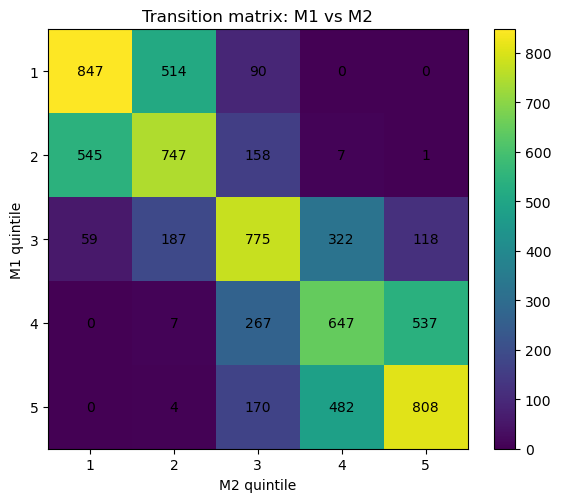

In [5]:

# ---------------------------------
# 5. Simple heatmap using matplotlib
# ---------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(transition_counts.values)

ax.set_xticks(range(5))
ax.set_yticks(range(5))
ax.set_xticklabels([1, 2, 3, 4, 5])
ax.set_yticklabels([1, 2, 3, 4, 5])

ax.set_xlabel("M2 quintile")
ax.set_ylabel("M1 quintile")
ax.set_title("Transition matrix: M1 vs M2")

# Annotate cells
for i in range(transition_counts.shape[0]):
    for j in range(transition_counts.shape[1]):
        ax.text(j, i, transition_counts.iloc[i, j], ha="center", va="center")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()